# P1
Everyday too many flights are cancelled or delayed due to several reasons like the weather, operational issues, war etc. So I want to predict the delay time of the flights.

I have collected flight data from various sites like flightaware, flightera and openmeteor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("turkiye_ucuslari_filled.csv")

In [3]:
df.head()

,tarih,kalkis_havalimani,kalkis_sehir,varis_havalimani,varis_bilgi,havayolu,ucus_kodu,plan_kalkis,gercek_kalkis,varis_zamani,...,hava_wind_gust,hava_vis_min_m,hava_cloud,varis_temp,varis_humidity,varis_precip_mm,varis_wind,varis_wind_gust,varis_vis_min_m,varis_cloud
0,2024-01-01,KYA,Konya,DUS,Dusseldorf(DUS / EDDL),SunExpress,XQ1326,04:30,04:46,06:15,...,7.2,NaN,99.0,6.5,84.0,0.5,24.6,47.5,NaN,NaN
1,2024-01-01,KYA,Konya,SAW,Istanbul(SAW / LTFJ),Turkish Airlines,TK7283,08:20,12:13,13:07,...,10.8,NaN,100.0,13.9,65.0,0.0,11.9,24.5,NaN,97.0
2,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK2033,09:50,09:57,11:20,...,10.8,NaN,100.0,11.9,83.0,0.0,14.2,25.9,NaN,62.0
3,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK2037,16:20,16:21,17:34,...,11.9,NaN,100.0,14.4,76.0,0.0,16.1,29.9,NaN,87.0
4,2024-01-01,KYA,Konya,IST,Istanbul(IST / LTFM),Turkish Airlines,TK6951,17:05,17:09,18:11,...,9.4,NaN,100.0,13.4,80.0,0.0,18.0,31.0,NaN,97.0


In [4]:
print("Before Clean Up:", len(df))
df = df.drop_duplicates()
df = df.drop(columns=['hava_vis_min_m', 'varis_vis_min_m'], errors='ignore')
def convert_numbers(time_str):
    if pd.isna(time_str):
        return np.nan
    
    time_str = str(time_str).strip()
    total = 0
    
    if 'h' in time_str:
        timea = time_str.split('h')
        total += int(timea[0].strip()) * 60
        minute = timea[1].replace('m', '').strip()
        if minute:
            total += int(minute)
    elif 'm' in time_str:
        total += int(time_str.replace('m', '').strip())
        
    return total

df['ucus_suresi_dk'] = df['ucus_suresi'].apply(convert_numbers)
df = df.drop(columns=['ucus_suresi']) 

print("After the cleanup:", len(df))
print("-" * 40)

df.info()


Before Clean Up: 589620
After the cleanup: 546153
----------------------------------------
<class 'pandas.DataFrame'>
Index: 546153 entries, 0 to 589619
Data columns (total 33 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   tarih              546153 non-null  str    
 1   kalkis_havalimani  546153 non-null  str    
 2   kalkis_sehir       546153 non-null  str    
 3   varis_havalimani   546153 non-null  str    
 4   varis_bilgi        546153 non-null  str    
 5   havayolu           546153 non-null  str    
 6   ucus_kodu          546153 non-null  str    
 7   plan_kalkis        546153 non-null  str    
 8   gercek_kalkis      534938 non-null  str    
 9   varis_zamani       534938 non-null  str    
 10  durum              540081 non-null  str    
 11  durum_kategori     540081 non-null  str    
 12  delay_dk           534938 non-null  float64
 13  ic_hat             546153 non-null  int64  
 14  ucak_tipi          530895

In [5]:
sns.set_theme(style="whitegrid")

df['tarih'] = pd.to_datetime(df['tarih'], errors='coerce')

saat_sutunlari = ['plan_kalkis', 'gercek_kalkis', 'varis_zamani']
for col in saat_sutunlari:
    temp_time = pd.to_datetime(df[col], format='%H:%M', errors='coerce')
    df[col + '_dk'] = temp_time.dt.hour * 60 + temp_time.dt.minute

df = df.drop(columns=saat_sutunlari)

df['is_cancelled'] = np.where(df['durum'] == 'Cancelled', 1, 0)
completed_flights_df = df[df['durum'] != 'Cancelled'].copy()
completed_flights_df['route'] = completed_flights_df['kalkis_havalimani'] + " -> " + completed_flights_df['varis_havalimani']
completed_flights_df['is_delayed'] = completed_flights_df['delay_dk'] > 15

First, we look at the distribution of our target variable (`delay_dk`) and the extreme outliers.

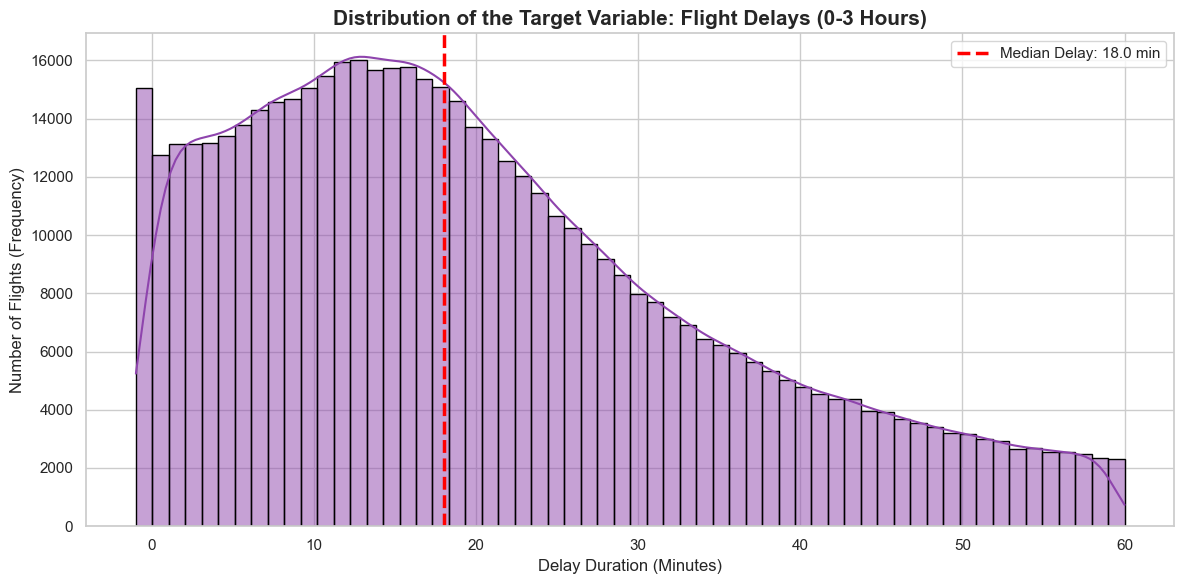

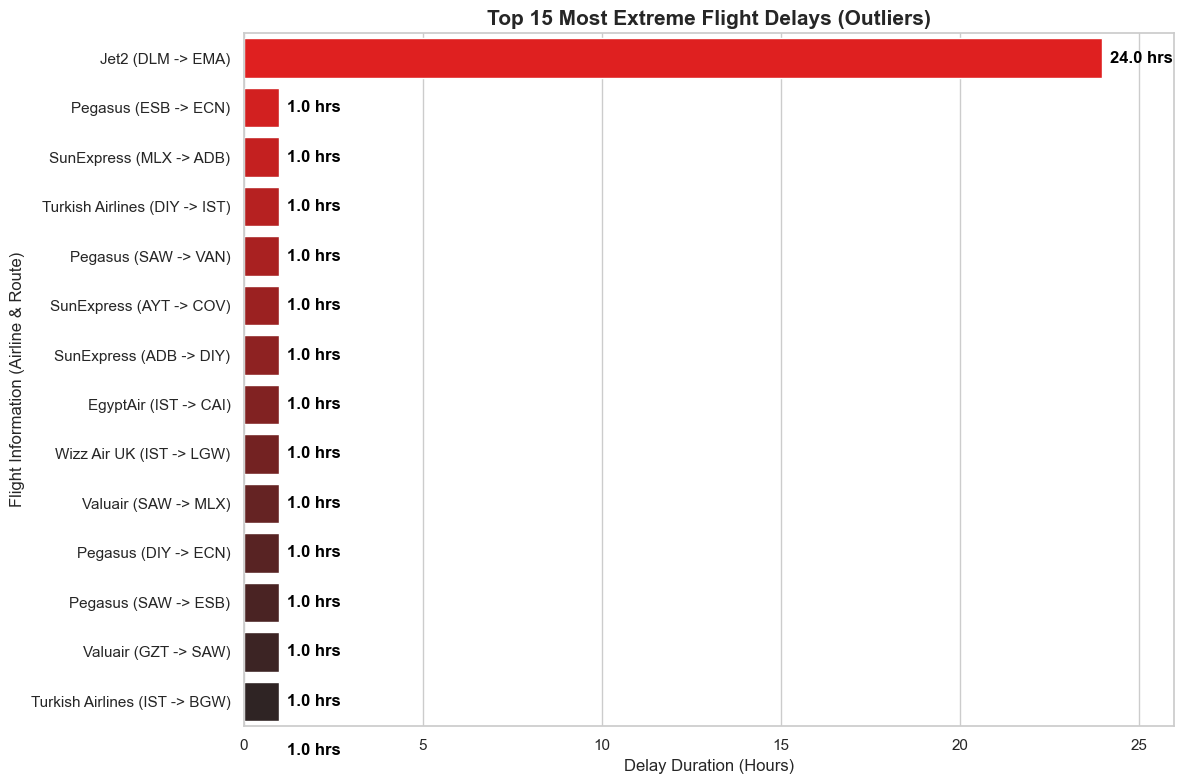

In [6]:
plt.figure(figsize=(12, 6))
normal_delays = completed_flights_df[completed_flights_df['delay_dk'] <= 180]

sns.histplot(data=normal_delays, x='delay_dk', bins=60, kde=True, color="#8e44ad", edgecolor="black")
plt.title('Distribution of the Target Variable: Flight Delays (0-3 Hours)', fontsize=15, fontweight='bold')
plt.xlabel('Delay Duration (Minutes)')
plt.ylabel('Number of Flights (Frequency)')

median_delay = normal_delays['delay_dk'].median()
plt.axvline(median_delay, color='red', linestyle='--', linewidth=2.5, label=f'Median Delay: {median_delay:.1f} min')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
extreme_delays = completed_flights_df.sort_values(by='delay_dk', ascending=False).head(15).copy()
extreme_delays['delay_hours'] = extreme_delays['delay_dk'] / 60
extreme_delays['flight_info'] = extreme_delays['havayolu'] + " (" + extreme_delays['route'] + ")"

sns.barplot(x=extreme_delays['delay_hours'], y=extreme_delays['flight_info'], 
            hue=extreme_delays['flight_info'], palette="dark:red_r", legend=False)
plt.title('Top 15 Most Extreme Flight Delays (Outliers)', fontsize=15, fontweight='bold')
plt.xlabel('Delay Duration (Hours)')
plt.ylabel('Flight Information (Airline & Route)')

for i, v in enumerate(extreme_delays['delay_hours']):
    plt.text(v + 0.2, i, f"{v:.1f} hrs", va='center', fontweight='bold', color='black')

plt.xlim(0, extreme_delays['delay_hours'].max() + 2)
plt.tight_layout()
plt.show()

Finding the busiest routes and delay times day to day

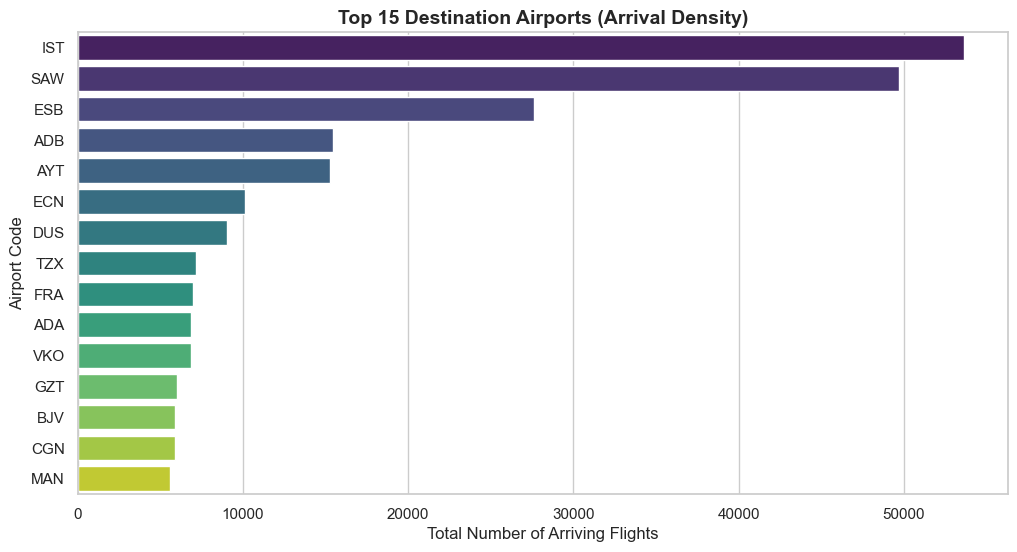

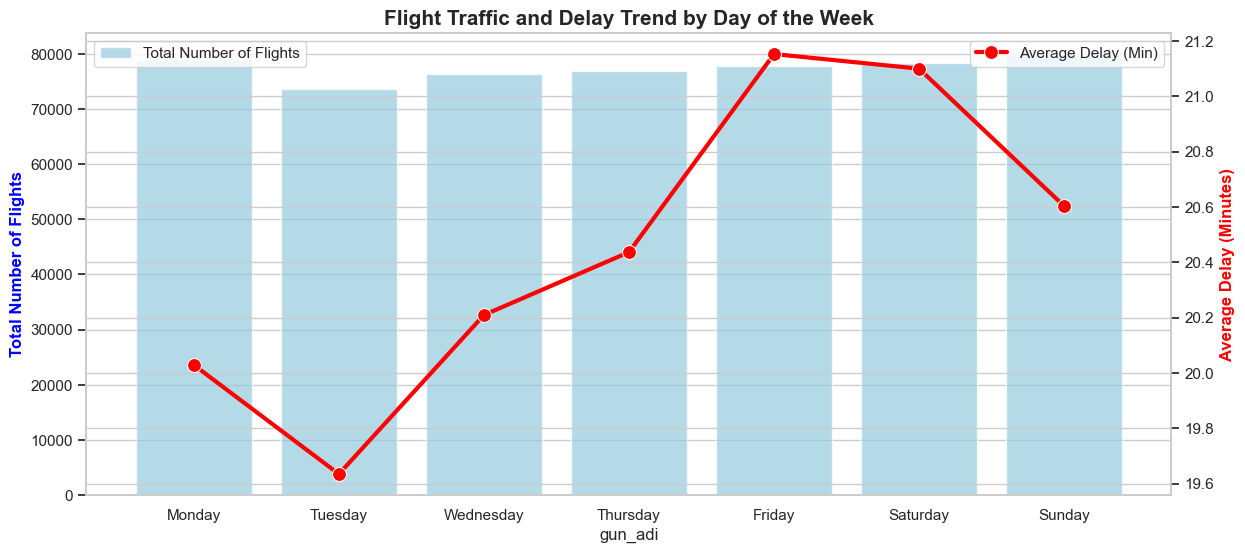

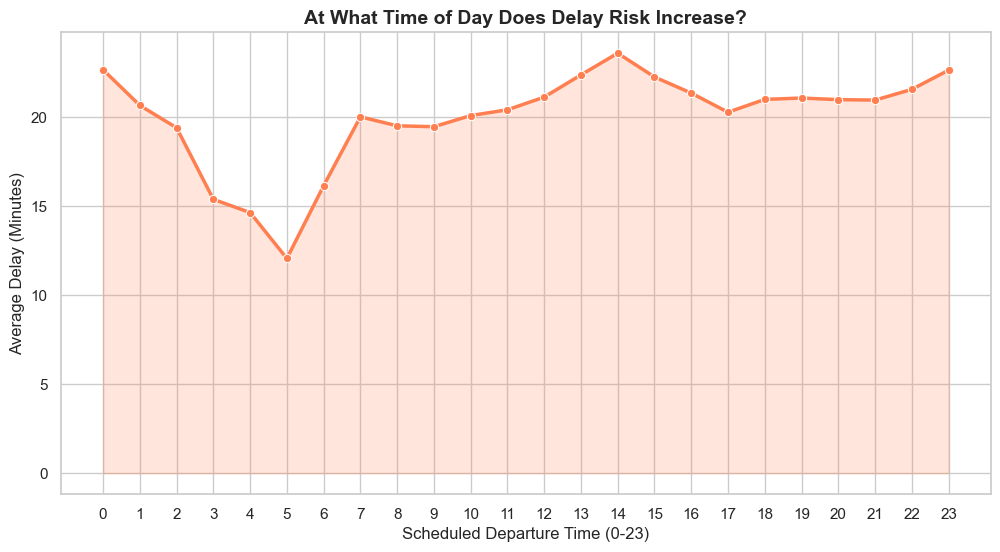

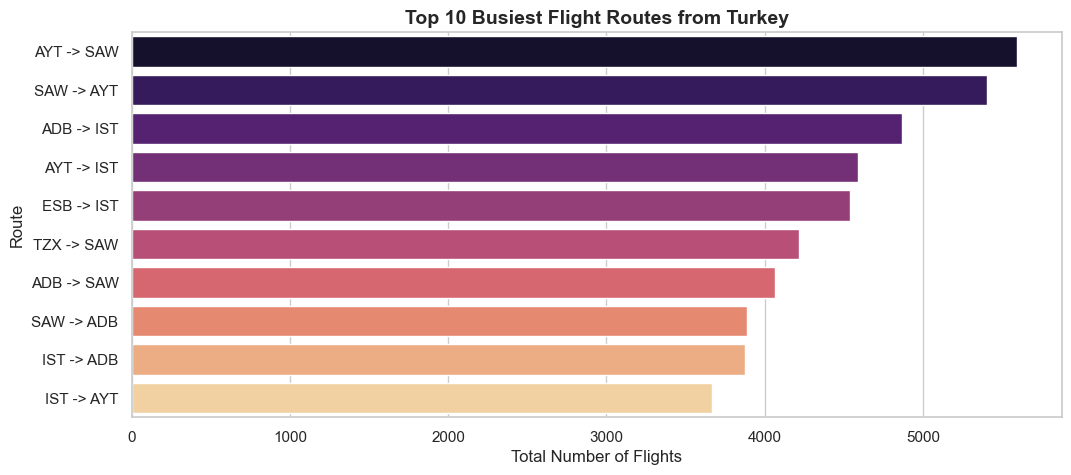

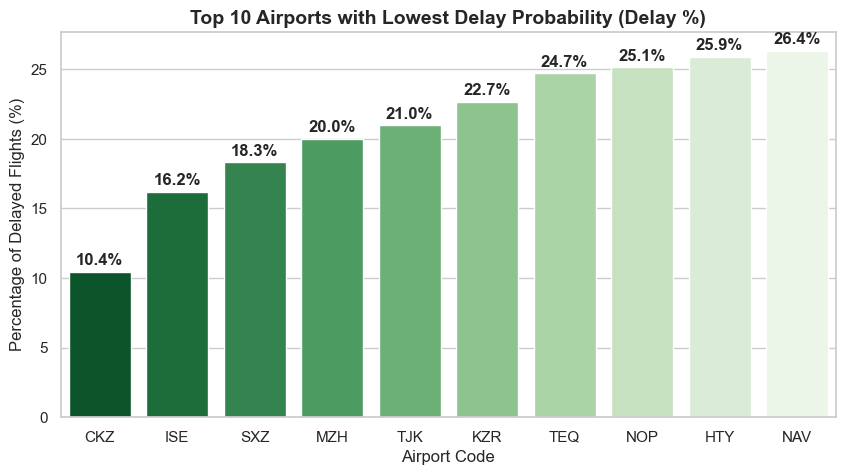

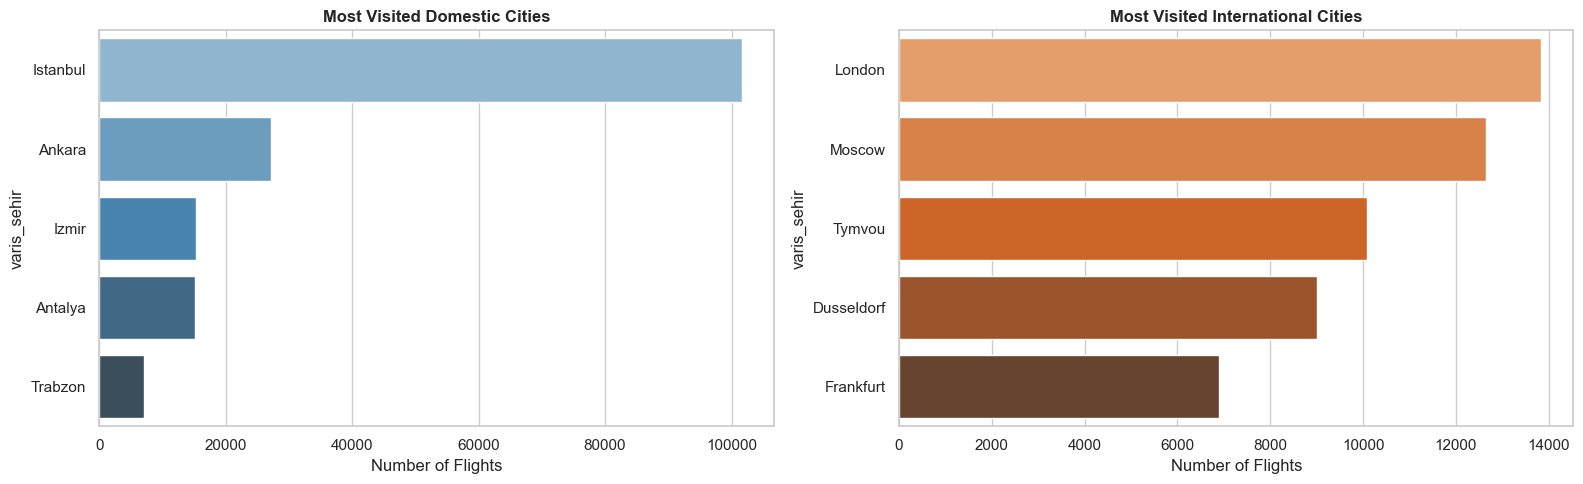

In [7]:
plt.figure(figsize=(12, 6))
top_destinations = df['varis_havalimani'].value_counts().head(15)
sns.barplot(x=top_destinations.values, y=top_destinations.index, hue=top_destinations.index, palette="viridis", legend=False)
plt.title('Top 15 Destination Airports (Arrival Density)', fontsize=14, fontweight='bold')
plt.xlabel('Total Number of Arriving Flights')
plt.ylabel('Airport Code')
plt.show()

plt.figure(figsize=(14, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
completed_flights_df['gun_adi'] = pd.Categorical(completed_flights_df['gun_adi'], categories=day_order, ordered=True)
daily_flights = completed_flights_df['gun_adi'].value_counts().sort_index()
daily_delays = completed_flights_df.groupby('gun_adi')['delay_dk'].mean()

ax1 = plt.gca()
ax2 = ax1.twinx()
sns.barplot(x=daily_flights.index, y=daily_flights.values, ax=ax1, color="skyblue", alpha=0.7, label="Total Number of Flights")
sns.lineplot(x=daily_delays.index, y=daily_delays.values, ax=ax2, color="red", marker="o", linewidth=3, markersize=10, label="Average Delay (Min)")
ax1.set_ylabel('Total Number of Flights', color="blue", fontweight='bold')
ax2.set_ylabel('Average Delay (Minutes)', color="red", fontweight='bold')
plt.title('Flight Traffic and Delay Trend by Day of the Week', fontsize=15, fontweight='bold')
plt.show()

plt.figure(figsize=(12, 6))
hourly_delay = completed_flights_df.groupby('kalkis_saati')['delay_dk'].mean()
sns.lineplot(x=hourly_delay.index, y=hourly_delay.values, marker="o", color="coral", linewidth=2.5)
plt.title('At What Time of Day Does Delay Risk Increase?', fontsize=14, fontweight='bold')
plt.xlabel('Scheduled Departure Time (0-23)')
plt.ylabel('Average Delay (Minutes)')
plt.xticks(range(0, 24))
plt.fill_between(hourly_delay.index, hourly_delay.values, alpha=0.2, color="coral") 
plt.show()

completed_flights_df['rota'] = completed_flights_df['kalkis_havalimani'] + " -> " + completed_flights_df['varis_havalimani']
top_routes = completed_flights_df['rota'].value_counts().head(10)

plt.figure(figsize=(12, 5))

sns.barplot(x=top_routes.values, y=top_routes.index, hue=top_routes.index, palette="magma", legend=False)
plt.title('Top 10 Busiest Flight Routes from Turkey', fontsize=14, fontweight='bold')
plt.xlabel('Total Number of Flights')
plt.ylabel('Route')
plt.show()
completed_flights_df['rotarli_mi'] = completed_flights_df['delay_dk'] > 15

airport_delays = completed_flights_df.groupby('kalkis_havalimani').agg(
    toplam_ucus=('rotarli_mi', 'count'),
    rotarli_ucus=('rotarli_mi', 'sum')
)
airport_delays = airport_delays[airport_delays['toplam_ucus'] > 50] # Only busy airports
airport_delays['rotar_yuzdesi'] = (airport_delays['rotarli_ucus'] / airport_delays['toplam_ucus']) * 100


best_airports = airport_delays.sort_values('rotar_yuzdesi').head(10)

plt.figure(figsize=(10, 5))

sns.barplot(x=best_airports.index, y=best_airports['rotar_yuzdesi'], hue=best_airports.index, palette="Greens_r", legend=False)
plt.title('Top 10 Airports with Lowest Delay Probability (Delay %)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Delayed Flights (%)')
plt.xlabel('Airport Code')
for i, v in enumerate(best_airports['rotar_yuzdesi']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()

completed_flights_df['varis_sehir'] = completed_flights_df['varis_bilgi'].apply(lambda x: str(x).split('(')[0].strip() if pd.notnull(x) else x)

top_domestic = completed_flights_df[completed_flights_df['ic_hat'] == 1]['varis_sehir'].value_counts().head(5)
top_international = completed_flights_df[completed_flights_df['ic_hat'] == 0]['varis_sehir'].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=top_domestic.values, y=top_domestic.index, ax=axes[0], hue=top_domestic.index, palette="Blues_d", legend=False)
axes[0].set_title('Most Visited Domestic Cities', fontweight='bold')
axes[0].set_xlabel('Number of Flights')

sns.barplot(x=top_international.values, y=top_international.index, ax=axes[1], hue=top_international.index, palette="Oranges_d", legend=False)
axes[1].set_title('Most Visited International Cities', fontweight='bold')
axes[1].set_xlabel('Number of Flights')

plt.tight_layout()
plt.show()


evaluating airlines based on their average delay times, punctuality percentages, and cancellation rates.

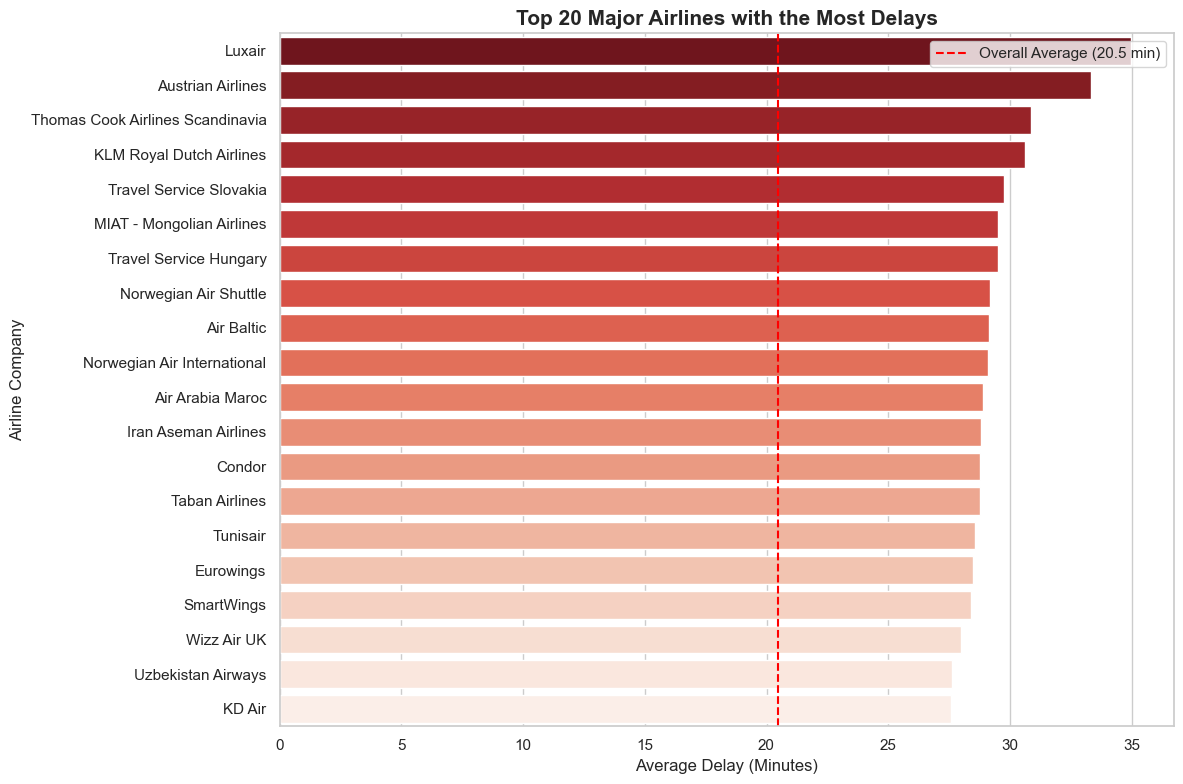

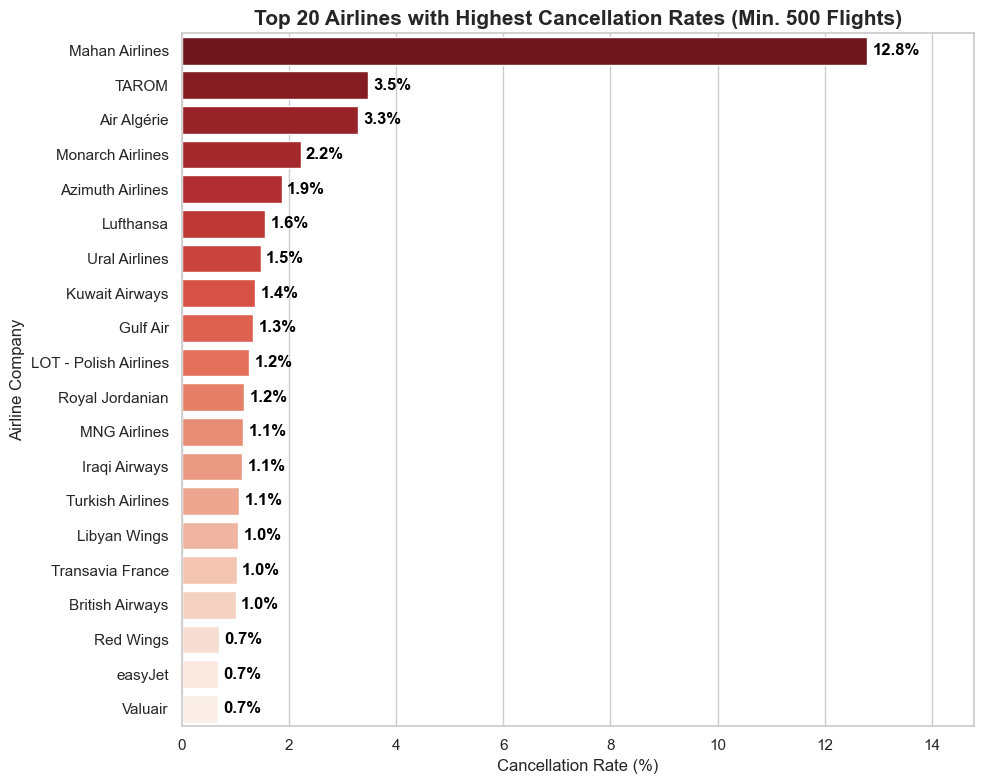

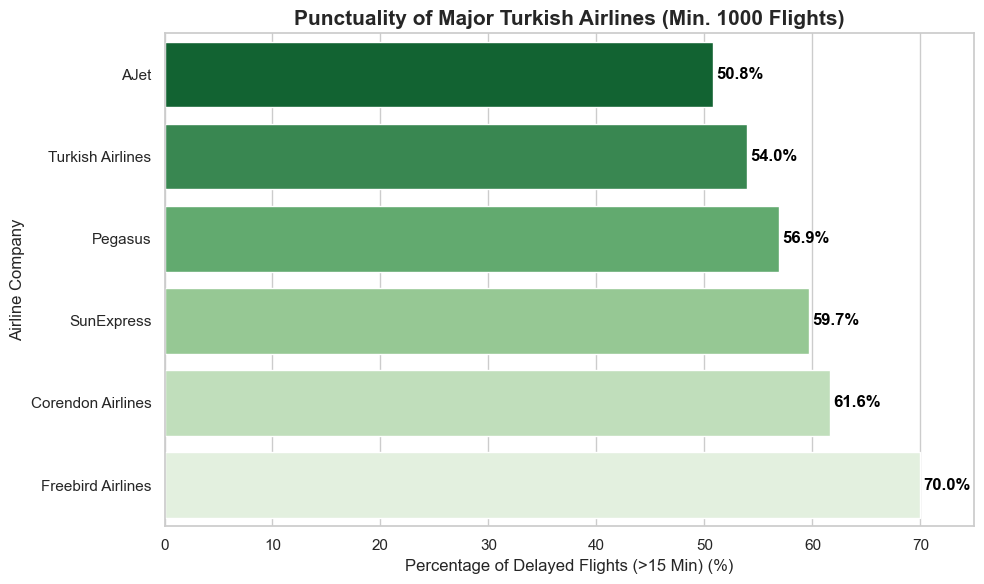

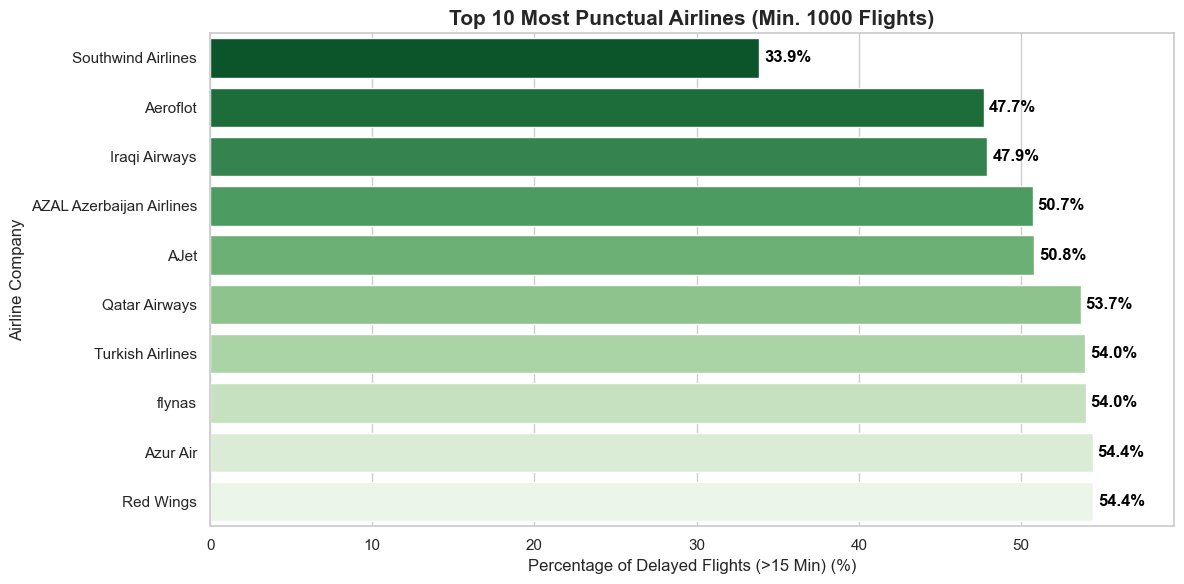

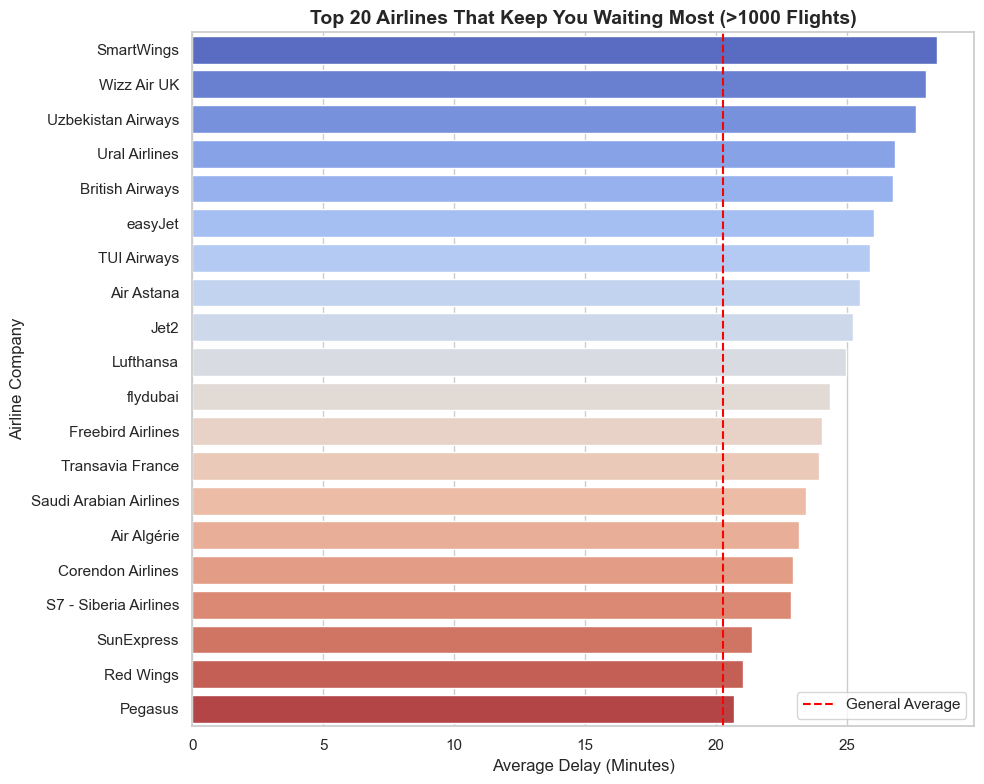

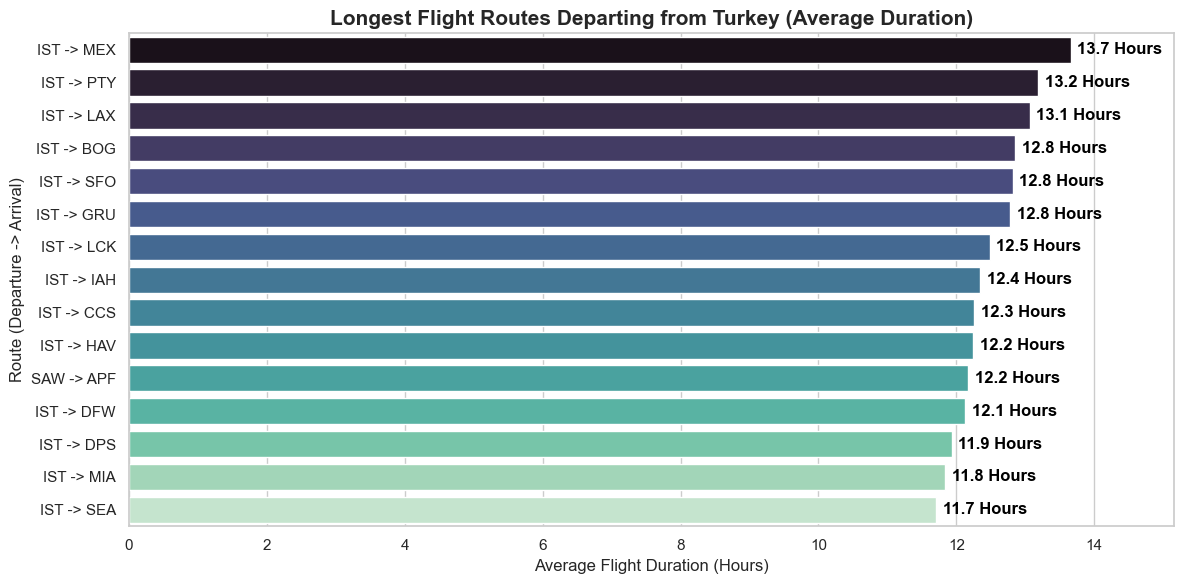

In [8]:
plt.figure(figsize=(12, 8))
airline_flight_counts = completed_flights_df['havayolu'].value_counts()
major_airlines = airline_flight_counts[airline_flight_counts > 50].index
filtered_df = completed_flights_df[completed_flights_df['havayolu'].isin(major_airlines)]
avg_delay = filtered_df.groupby('havayolu')['delay_dk'].mean().sort_values(ascending=False).head(20)

sns.barplot(x=avg_delay.values, y=avg_delay.index, hue=avg_delay.index, palette="Reds_r", legend=False)
plt.title('Top 20 Major Airlines with the Most Delays', fontsize=15, fontweight='bold')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Airline Company')
overall_avg_delay = completed_flights_df['delay_dk'].mean()
plt.axvline(x=overall_avg_delay, color='red', linestyle='--', label=f'Overall Average ({overall_avg_delay:.1f} min)')
plt.legend()
plt.tight_layout() 
plt.show()

plt.figure(figsize=(10, 8))
airline_cancellations = df.groupby('havayolu').agg(
    total_flights=('is_cancelled', 'count'),
    cancelled_flights=('is_cancelled', 'sum')
)
airline_cancellations = airline_cancellations[airline_cancellations['total_flights'] >= 500]
airline_cancellations['cancel_percentage'] = (airline_cancellations['cancelled_flights'] / airline_cancellations['total_flights']) * 100
top_cancellations = airline_cancellations.sort_values('cancel_percentage', ascending=False).head(20)

sns.barplot(x=top_cancellations['cancel_percentage'], y=top_cancellations.index, 
            hue=top_cancellations.index, palette="Reds_r", legend=False)
plt.title('Top 20 Airlines with Highest Cancellation Rates (Min. 500 Flights)', fontsize=15, fontweight='bold')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Airline Company')
for i, v in enumerate(top_cancellations['cancel_percentage']):
    plt.text(v + 0.1, i, f"{v:.1f}%", va='center', fontweight='bold', color='black')
plt.xlim(0, top_cancellations['cancel_percentage'].max() + 2) 
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
completed_flights_df['havayolu'] = completed_flights_df['havayolu'].replace(
    ['valuair', 'Valuair', 'AnadoluJet'], 'AJet'
).replace(
    ['turkish airlines', 'Turkish airlines', 'TURKISH AIRLINES'], 'Turkish Airlines'
)

turkish_airlines = ['Turkish Airlines', 'Pegasus', 'SunExpress', 'AJet', 'Corendon Airlines', 'Freebird Airlines', 'Tailwind Airlines']
tr_flights_df = completed_flights_df[completed_flights_df['havayolu'].isin(turkish_airlines)].copy()
tr_flights_df['is_delayed'] = tr_flights_df['delay_dk'] > 15

airline_punctuality = tr_flights_df.groupby('havayolu').agg(
    total_flights=('is_delayed', 'count'),
    delayed_flights=('is_delayed', 'sum')
)
airline_punctuality = airline_punctuality[airline_punctuality['total_flights'] >= 1000]
airline_punctuality['delay_percentage'] = (airline_punctuality['delayed_flights'] / airline_punctuality['total_flights']) * 100
most_punctual_airlines = airline_punctuality.sort_values('delay_percentage')

sns.barplot(x=most_punctual_airlines['delay_percentage'], y=most_punctual_airlines.index, hue=most_punctual_airlines.index, palette="Greens_r", legend=False)
plt.title('Punctuality of Major Turkish Airlines (Min. 1000 Flights)', fontsize=15, fontweight='bold')
plt.xlabel('Percentage of Delayed Flights (>15 Min) (%)')
plt.ylabel('Airline Company')
for i, v in enumerate(most_punctual_airlines['delay_percentage']):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center', fontweight='bold', color='black')
plt.xlim(0, most_punctual_airlines['delay_percentage'].max() + 5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

completed_flights_df['is_delayed'] = completed_flights_df['delay_dk'] > 15

airline_punctuality = completed_flights_df.groupby('havayolu').agg(
    total_flights=('is_delayed', 'count'),
    delayed_flights=('is_delayed', 'sum')
)

airline_punctuality = airline_punctuality[airline_punctuality['total_flights'] >= 1000]

airline_punctuality['delay_percentage'] = (airline_punctuality['delayed_flights'] / airline_punctuality['total_flights']) * 100

most_punctual_airlines = airline_punctuality.sort_values('delay_percentage').head(10)

sns.barplot(x=most_punctual_airlines['delay_percentage'], y=most_punctual_airlines.index, hue=most_punctual_airlines.index, palette="Greens_r", legend=False)

plt.title('Top 10 Most Punctual Airlines (Min. 1000 Flights)', fontsize=15, fontweight='bold')
plt.xlabel('Percentage of Delayed Flights (>15 Min) (%)')
plt.ylabel('Airline Company')

for i, v in enumerate(most_punctual_airlines['delay_percentage']):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center', fontweight='bold', color='black')

plt.xlim(0, most_punctual_airlines['delay_percentage'].max() + 5) 
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

airline_flight_counts = completed_flights_df['havayolu'].value_counts()
major_airlines = airline_flight_counts[airline_flight_counts > 1000].index
filtered_df = completed_flights_df[completed_flights_df['havayolu'].isin(major_airlines)]

avg_delay = filtered_df.groupby('havayolu')['delay_dk'].mean().sort_values(ascending=False).head(20)

sns.barplot(x=avg_delay.values, y=avg_delay.index, hue=avg_delay.index, palette="coolwarm", legend=False)
plt.title('Top 20 Airlines That Keep You Waiting Most (>1000 Flights)', fontsize=14, fontweight='bold')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Airline Company')

plt.axvline(x=filtered_df['delay_dk'].mean(), color='red', linestyle='--', label='General Average') 
plt.legend()
plt.tight_layout()
plt.show()

completed_flights_df = df[df['durum'] != 'Cancelled'].copy()

completed_flights_df['route'] = completed_flights_df['kalkis_havalimani'] + " -> " + completed_flights_df['varis_havalimani']
plt.figure(figsize=(12, 6))

route_durations = completed_flights_df.groupby('route')['ucus_suresi_dk'].mean().sort_values(ascending=False).head(15)
route_durations_hours = route_durations / 60

sns.barplot(x=route_durations_hours.values, y=route_durations_hours.index, hue=route_durations_hours.index, palette="mako", legend=False)
plt.title('Longest Flight Routes Departing from Turkey (Average Duration)', fontsize=15, fontweight='bold')
plt.xlabel('Average Flight Duration (Hours)')
plt.ylabel('Route (Departure -> Arrival)')

for i, v in enumerate(route_durations_hours.values):
    plt.text(v + 0.1, i, f"{v:.1f} Hours", va='center', fontweight='bold', color='black')

plt.xlim(0, route_durations_hours.max() + 1.5) 
plt.tight_layout()
plt.show()

visualizing weather impact

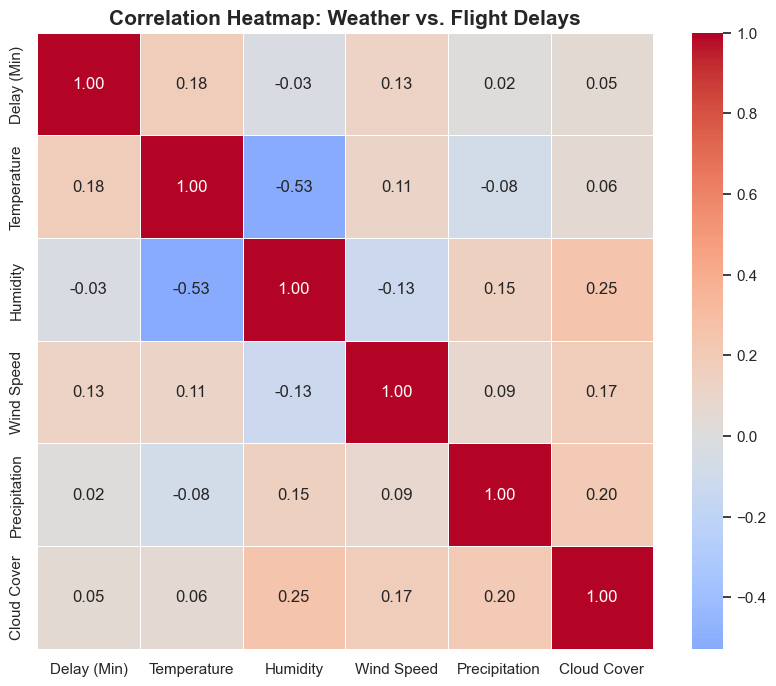

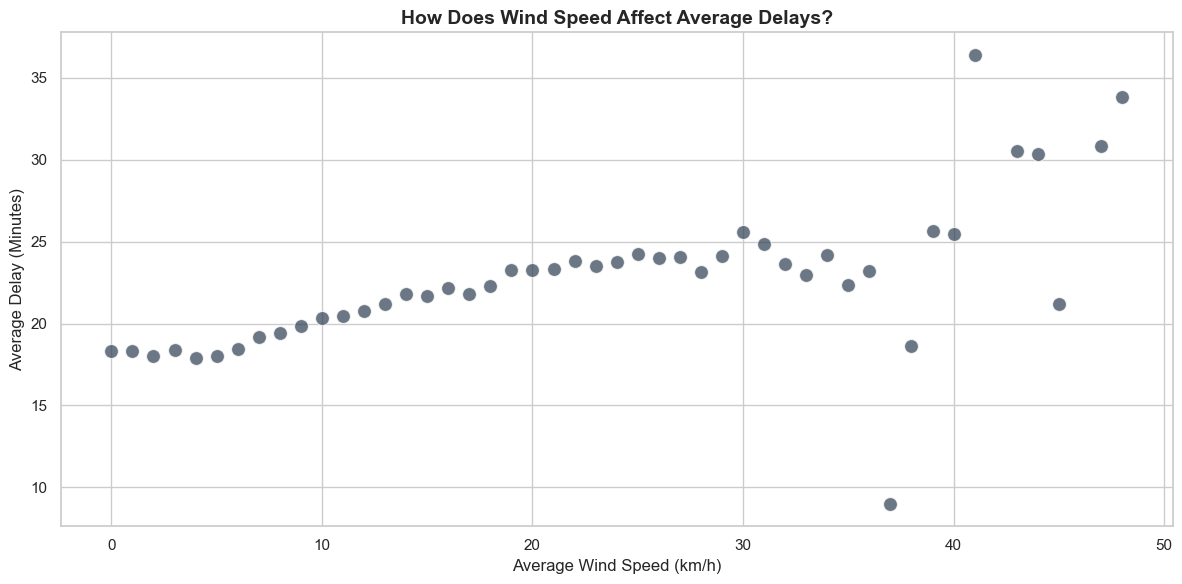

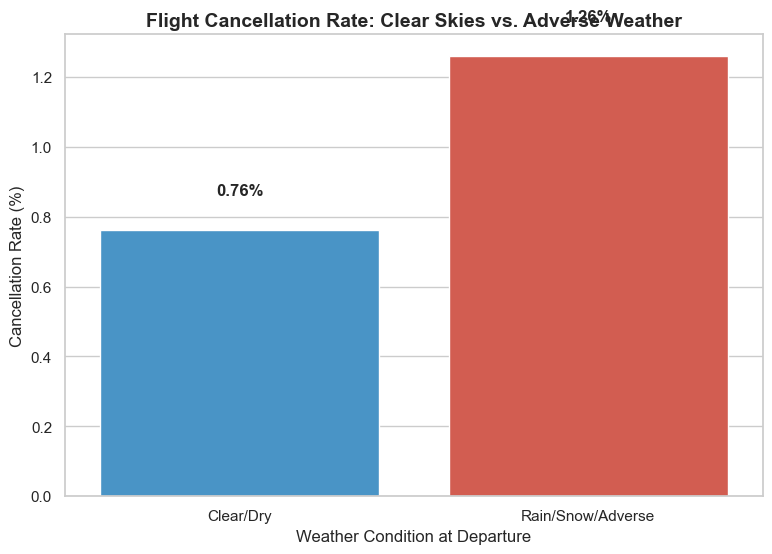

In [9]:
plt.figure(figsize=(10, 8))
weather_cols = ['delay_dk', 'hava_temp', 'hava_humidity', 'hava_wind', 'hava_precip_mm', 'hava_cloud']
weather_names = ['Delay (Min)', 'Temperature', 'Humidity', 'Wind Speed', 'Precipitation', 'Cloud Cover']
corr_matrix = completed_flights_df[weather_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            xticklabels=weather_names, yticklabels=weather_names, square=True, linewidths=.5)
plt.title('Correlation Heatmap: Weather vs. Flight Delays', fontsize=15, fontweight='bold')
plt.show()

plt.figure(figsize=(12, 6))

completed_flights_df['rounded_wind'] = completed_flights_df['hava_wind'].round()
wind_impact = completed_flights_df.groupby('rounded_wind')['delay_dk'].mean()

wind_impact = wind_impact[wind_impact.index < 50] 

sns.scatterplot(x=wind_impact.index, y=wind_impact.values, s=100, alpha=0.7, color='#2c3e50', edgecolor='white')

plt.title('How Does Wind Speed Affect Average Delays?', fontsize=14, fontweight='bold')
plt.xlabel('Average Wind Speed (km/h)')
plt.ylabel('Average Delay (Minutes)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
df['weather_condition'] = np.where(df['hava_precip_mm'] > 0, 'Rain/Snow/Adverse', 'Clear/Dry')
cancel_rate_precip = df.groupby('weather_condition')['is_cancelled'].mean() * 100

sns.barplot(x=cancel_rate_precip.index, y=cancel_rate_precip.values, 
            hue=cancel_rate_precip.index, palette=["#3498db", "#e74c3c"], legend=False)
plt.title('Flight Cancellation Rate: Clear Skies vs. Adverse Weather', fontsize=14, fontweight='bold')
plt.xlabel('Weather Condition at Departure')
plt.ylabel('Cancellation Rate (%)')
for i, v in enumerate(cancel_rate_precip.values):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)
plt.show()

how freezing temperatures cancel the flights and which aircraft types delay more

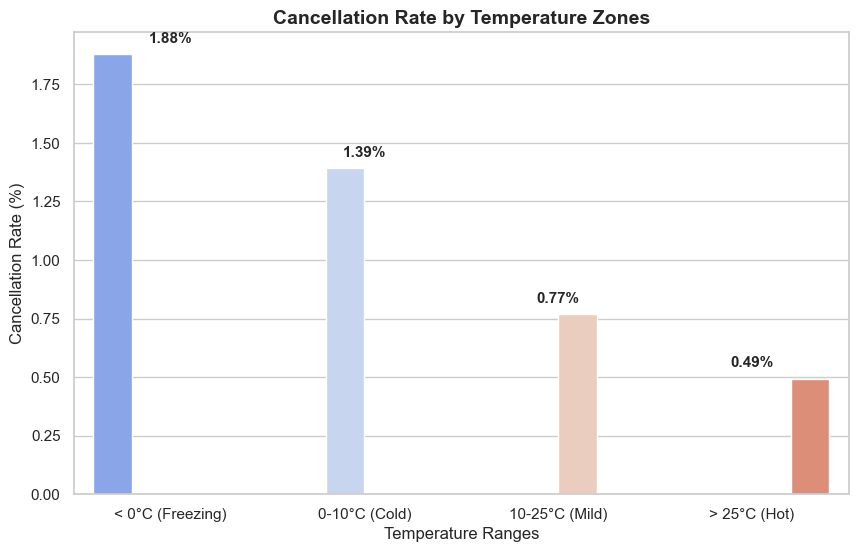

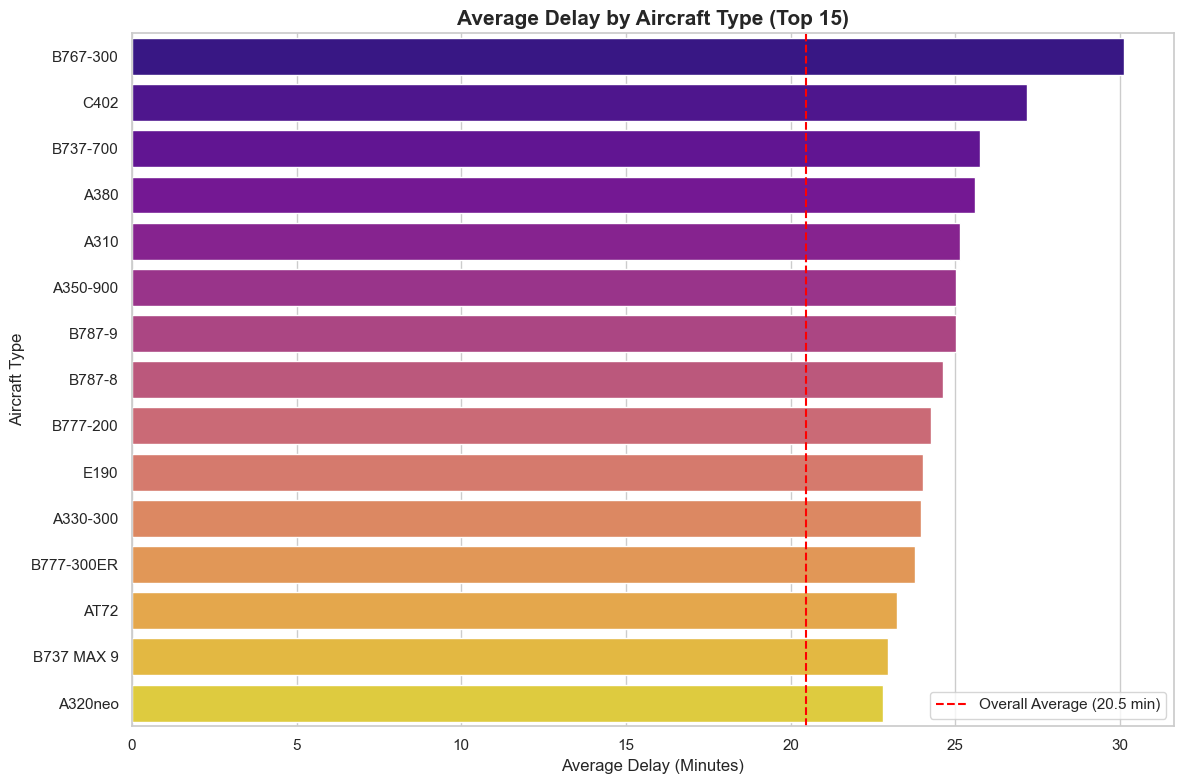

In [10]:
plt.figure(figsize=(10, 6))
df['temp_bin'] = pd.cut(df['hava_temp'], 
                        bins=[-50, 0, 10, 25, 50], 
                        labels=['< 0°C (Freezing)', '0-10°C (Cold)', '10-25°C (Mild)', '> 25°C (Hot)'])

temp_cancel = df.groupby('temp_bin', observed=True)['is_cancelled'].mean() * 100

sns.barplot(x=temp_cancel.index, y=temp_cancel.values, hue=temp_cancel.index, palette="coolwarm", legend=False)
plt.title('Cancellation Rate by Temperature Zones', fontsize=14, fontweight='bold')
plt.xlabel('Temperature Ranges')
plt.ylabel('Cancellation Rate (%)')
for i, v in enumerate(temp_cancel.values):
    if not pd.isna(v):
        plt.text(i, v + 0.05, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)
plt.show()

plt.figure(figsize=(12, 8))
aircraft_counts = completed_flights_df['ucak_tipi'].value_counts()
major_aircraft = aircraft_counts[aircraft_counts > 50].index
filtered_aircraft_df = completed_flights_df[completed_flights_df['ucak_tipi'].isin(major_aircraft)]
avg_delay_aircraft = filtered_aircraft_df.groupby('ucak_tipi')['delay_dk'].mean().sort_values(ascending=False).head(15)

sns.barplot(x=avg_delay_aircraft.values, y=avg_delay_aircraft.index, hue=avg_delay_aircraft.index, palette="plasma", legend=False)
plt.title('Average Delay by Aircraft Type (Top 15)', fontsize=15, fontweight='bold')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Aircraft Type')
overall_avg = completed_flights_df['delay_dk'].mean()
plt.axvline(x=overall_avg, color='red', linestyle='--', label=f'Overall Average ({overall_avg:.1f} min)')
plt.legend()
plt.tight_layout()
plt.show()